In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn import datasets

data = datasets.load_diabetes()

data

X = data.data
y = data.target

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=8)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

model = LogisticRegression()
model.fit(X_train_poly, y_train)


output = model.predict(X_test_poly)

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  y_type = type_of_target(y, input_name="y")


In [4]:
output_train = model.predict(X_train_poly)

from sklearn.metrics import mean_squared_error

mse_train = mean_squared_error(y_train, output_train)
mse_test = mean_squared_error(y_test, output)

print("MSE for training data:", mse_train)
print("MSE for test data:", mse_test)

MSE for training data: 0.0
MSE for test data: 4795.224719101124


In [5]:
print("R Squared for test data:")
print(model.score(X_test_poly, y_test))
print("R Squared for train data:")
print(model.score(X_train_poly, y_train))

R Squared for test data:
0.011235955056179775
R Squared for train data:
1.0


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  type_pred = type_of_target(y

Lasso(alpha = 0.1) --> This is L1 Regularization, Linear regression with sum of absolute values of coefficients

ridge(alpha = 0.1) --> This is L2 Regularization, Linear regression with sum of square of values of coefficients

In [11]:
from sklearn.linear_model import Lasso, Ridge

lasso = Lasso(alpha=0.05)
ridge = Ridge(alpha=0.05)

lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)

print("Lasso R square Score train:", lasso.score(X_train, y_train))
print("Ridge R square Score train :", ridge.score(X_train, y_train))
print("Lasso R square Score test:", lasso.score(X_test, y_test))
print("Ridge R square Score test :", ridge.score(X_test, y_test))

lasso_output_train = lasso.predict(X_train)
ridge_output_train = ridge.predict(X_train)
lasso_output_test = lasso.predict(X_test)
ridge_output_test = ridge.predict(X_test)

mse_lasso_train = mean_squared_error(y_train, lasso_output_train)
mse_ridge_train = mean_squared_error(y_train, ridge_output_train)

mse_lasso_test = mean_squared_error(y_test, lasso_output_test)
mse_ridge_test = mean_squared_error(y_test, ridge_output_test)

print("Lasso MSE train:", mse_lasso_train)
print("Ridge MSE train:", mse_ridge_train)
print("Lasso MSE test:", mse_lasso_test)
print("Ridge MSE test:", mse_ridge_test)


Lasso R square Score train: 0.0
Ridge R square Score train : 0.25132182035485184
Lasso R square Score test: -0.011962984778542296
Ridge R square Score test : 0.2499191763884867
Lasso MSE train: 6076.398012984615
Ridge MSE train: 4549.266603160717
Lasso MSE test: 5361.533457238513
Ridge MSE test: 3974.042027146111


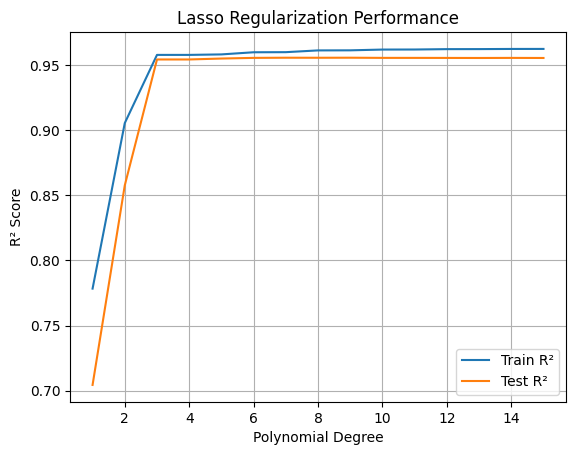

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split

# Generate synthetic data
np.random.seed(0)
X = np.linspace(-3, 3, 200).reshape(-1, 1)  # shape: (200, 1)
y = 0.5 * X[:, 0]**3 - X[:, 0]**2 + X[:, 0] + np.random.normal(0, 1.5, size=200)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Polynomial degrees
max_degree = 15
train_scores = []
test_scores = []

for degree in range(1, max_degree + 1):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    scaler = StandardScaler()
    X_train_poly = scaler.fit_transform(X_train_poly)
    X_test_poly = scaler.transform(X_test_poly)

    lasso = Lasso(alpha=0.1, max_iter=10000)
    lasso.fit(X_train_poly, y_train)

    train_scores.append(lasso.score(X_train_poly, y_train))
    test_scores.append(lasso.score(X_test_poly, y_test))

# Plotting
plt.plot(range(1, max_degree + 1), train_scores, label='Train R²')
plt.plot(range(1, max_degree + 1), test_scores, label='Test R²')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Lasso Regularization Performance')
plt.legend()
plt.grid(True)
plt.show()


Cross Validation:

Data --> Train Data + Hyperparameter Data + Test Data (70% + 15% + 15% or 80% + 10% + 10%)



K-Fold Cross Validation


Change the combinations of the data for test, train and hyperparameter data to get a better model

Logloss Formula:

